
===== FEATURES ENZO =====
AUC = 336.53
dSmO2 max = 13.02
slope = -0.521
tau = 2.51

===== LACTATE PREDICTION =====
Delta peak = 14.11
Peak lactate = 15.61


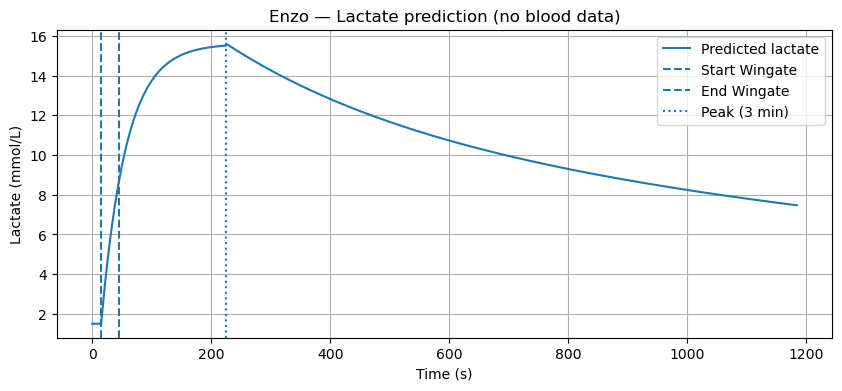

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1) PARAMETERS
CSV_FILE = "Enzo_wingate.csv"

START_TIME_S = 15
WINGATE_DURATION = 30
END_TIME_S = START_TIME_S + WINGATE_DURATION

# FIXED MODEL ASSUMPTIONS
T_PEAK_MIN = 3
T_PEAK_S = END_TIME_S + T_PEAK_MIN * 60

LA_BASELINE = 1.5  # assumed

# SmO2 baseline 
SMO2_BASELINE = 70

# MODEL 2 COEFFICIENTS 

B0 = 9.4178  # intercept
B1 = 0.011459  # AUC_30s
B2 = 0.178943  # tau_SmO2
B3 = 0.029526  # dSmO2_max
B4 = -0.012427   # slope_0_10


# LOAD CSV

def load_csv(file_path):
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines):
        if "Timestamp (seconds passed)" in line and "SmO2" in line:
            header_idx = i
            break

    df = pd.read_csv(file_path, skiprows=header_idx)
    df.columns = [str(c).strip() for c in df.columns]

    df = df[["Timestamp (seconds passed)", "SmO2"]]
    df.columns = ["Time", "SmO2"]

    df["Time"] = pd.to_numeric(df["Time"], errors="coerce")
    df["SmO2"] = pd.to_numeric(df["SmO2"], errors="coerce")

    return df.dropna().sort_values("Time").reset_index(drop=True)

sm = load_csv(CSV_FILE)


# FEATURES

wing = sm[(sm["Time"] >= START_TIME_S) &
          (sm["Time"] <= END_TIME_S)].copy()

wing["t_rel"] = wing["Time"] - START_TIME_S
wing["dSmO2"] = (SMO2_BASELINE - wing["SmO2"]).clip(lower=0)

dt = np.mean(np.diff(wing["Time"]))
AUC = np.sum(wing["dSmO2"]) * dt
dmax = wing["dSmO2"].max()

early = wing[wing["t_rel"] <= 10]
slope = np.polyfit(early["t_rel"], early["SmO2"], 1)[0]

# tau estimation

def model(t, A, tau):
    return A * (1 - np.exp(-t/tau))

t = wing["t_rel"].values
y = wing["dSmO2"].values

popt, _ = curve_fit(model, t, y, p0=[y.max(), 5])
A_fit, tau = popt

print("\n===== FEATURES ENZO =====")
print(f"AUC = {AUC:.2f}")
print(f"dSmO2 max = {dmax:.2f}")
print(f"slope = {slope:.3f}")
print(f"tau = {tau:.2f}")


# MODEL 2 PREDICTION

delta_peak = B0 + B1*AUC + B2*tau + B3*dmax + B4*slope
delta_peak = max(delta_peak, 0)

la_peak = LA_BASELINE + delta_peak

print("\n===== LACTATE PREDICTION =====")
print(f"Delta peak = {delta_peak:.2f}")
print(f"Peak lactate = {la_peak:.2f}")


# CURVE MODEL

def rise(frac):
    return 1 - np.exp(-5*frac)

def decay(t):
    return LA_BASELINE + delta_peak * (
        0.3*np.exp(-t/300) + 0.7*np.exp(-t/1800)
    )

pred = sm.copy()
pred["La"] = np.nan

for i, t in enumerate(pred["Time"]):

    if t < START_TIME_S:
        pred.loc[i, "La"] = LA_BASELINE

    elif t <= T_PEAK_S:
        frac = (t - START_TIME_S) / (T_PEAK_S - START_TIME_S)
        pred.loc[i, "La"] = LA_BASELINE + rise(frac)*delta_peak

    else:
        pred.loc[i, "La"] = decay(t - T_PEAK_S)


# PLOT

plt.figure(figsize=(10,4))
plt.plot(pred["Time"], pred["La"], label="Predicted lactate")
plt.axvline(START_TIME_S, linestyle="--", label="Start Wingate")
plt.axvline(END_TIME_S, linestyle="--", label="End Wingate")
plt.axvline(T_PEAK_S, linestyle=":", label="Peak (3 min)")
plt.xlabel("Time (s)")
plt.ylabel("Lactate (mmol/L)")
plt.title("Enzo — Lactate prediction (no blood data)")
plt.grid(True)
plt.legend()
plt.show()


===== ENZO VALIDATION TABLE =====
   Time_min  Time_abs_s  La_measured  La_predicted     Error  Absolute_error
0        -1         -45          2.6      1.500000 -1.100000        1.100000
1         0          45         15.6      8.705972 -6.894028        6.894028
2         4         285         18.6     14.522400 -4.077600        4.077600
3         6         405         13.3     12.763078 -0.536922        0.536922
4         8         525         12.0     11.420456 -0.579544        0.579544
5        12         765         12.1      9.518795 -2.581205        2.581205

===== ENZO VALIDATION METRICS =====
RMSE = 3.48 mmol/L
MAE  = 2.63 mmol/L
Bias = -2.63 mmol/L
R    = 0.89
R²   = 0.50


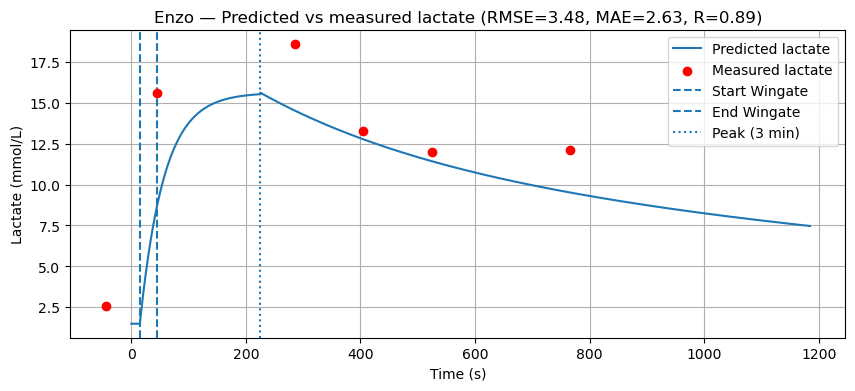

In [14]:
# ==========================================
# VALIDATION OF THE MODEL ON ENZO
# ==========================================

# Option 1: enter Enzo's measured lactate values directly here
enzo_measured = pd.DataFrame({
    "Time_min": [-1, 0, 4, 6, 8, 12],
    "La_measured": [2.6, 15.6, 18.6, 13.3, 12.0, 12.1]
})

# Convert lactate sampling times (in minutes) to absolute SmO2 time (in seconds)
abs_times = []
for tmin in enzo_measured["Time_min"]:
    if tmin == -1:
        # baseline point placed 60 s before Wingate start
        tabs = START_TIME_S - 60
    else:
        # post-exercise samples are positioned after the end of the Wingate
        tabs = END_TIME_S + tmin * 60
    abs_times.append(tabs)

enzo_measured["Time_abs_s"] = abs_times

# For each real lactate sample, find the closest predicted point
predicted_values = []
for tabs in enzo_measured["Time_abs_s"]:
    idx = np.argmin(np.abs(pred["Time"].values - tabs))
    predicted_values.append(pred.iloc[idx]["La"])

enzo_measured["La_predicted"] = predicted_values
enzo_measured["Error"] = enzo_measured["La_predicted"] - enzo_measured["La_measured"]
enzo_measured["Absolute_error"] = np.abs(enzo_measured["Error"])
enzo_measured["Squared_error"] = enzo_measured["Error"]**2

print("\n===== ENZO VALIDATION TABLE =====")
print(enzo_measured[[
    "Time_min",
    "Time_abs_s",
    "La_measured",
    "La_predicted",
    "Error",
    "Absolute_error"
]])

# Global validation metrics
rmse_enzo = np.sqrt(enzo_measured["Squared_error"].mean())
mae_enzo = enzo_measured["Absolute_error"].mean()
bias_enzo = enzo_measured["Error"].mean()

# R and R² can be informative, even with very few points
r_enzo = np.corrcoef(enzo_measured["La_measured"], enzo_measured["La_predicted"])[0, 1]
r2_enzo = 1 - (
    np.sum((enzo_measured["La_measured"] - enzo_measured["La_predicted"])**2)
    / np.sum((enzo_measured["La_measured"] - enzo_measured["La_measured"].mean())**2)
)

print("\n===== ENZO VALIDATION METRICS =====")
print(f"RMSE = {rmse_enzo:.2f} mmol/L")
print(f"MAE  = {mae_enzo:.2f} mmol/L")
print(f"Bias = {bias_enzo:.2f} mmol/L")
print(f"R    = {r_enzo:.2f}")
print(f"R²   = {r2_enzo:.2f}")

# ==========================================
# PLOT WITH MEASURED POINTS
# ==========================================

plt.figure(figsize=(10, 4))
plt.plot(pred["Time"], pred["La"], label="Predicted lactate")
plt.scatter(
    enzo_measured["Time_abs_s"],
    enzo_measured["La_measured"],
    color="red",
    label="Measured lactate",
    zorder=3
)

plt.axvline(START_TIME_S, linestyle="--", label="Start Wingate")
plt.axvline(END_TIME_S, linestyle="--", label="End Wingate")
plt.axvline(T_PEAK_S, linestyle=":", label="Peak (3 min)")

plt.xlabel("Time (s)")
plt.ylabel("Lactate (mmol/L)")
plt.title(
    f"Enzo — Predicted vs measured lactate "
    f"(RMSE={rmse_enzo:.2f}, MAE={mae_enzo:.2f}, R={r_enzo:.2f})"
)
plt.grid(True)
plt.legend()
plt.show()